# Track A — YOLOv8 차량 도장 결함 탐지 (Phase 1-B)

**목표**: `track_a_images/` 의 1,000장(train 800 / val 200) 이미지에 대해 YOLOv8n 결함 탐지 모델을 학습하고 mAP/클래스별 성능을 정량화한다. 추론 결과는 Phase 2 프로파일 매핑의 입력으로 CSV 저장한다.

**데이터 스키마**
- 이미지 크기: 1280×720 (고정)
- 클래스: 8개 (scratch/dent/paint_bubble/paint_drip/dust/orange_peel/crack/gap_fault)
- 라벨: YOLO 정규화 형식 `class cx cy w h`
- 결함 없는 이미지: train 133장, val 36장 (빈 라벨)

**파이프라인**
1. 환경 준비 · 데이터 사전 점검
2. `data.yaml` 검증 · 절대경로화
3. YOLOv8n 학습 (pretrained COCO, 50 epochs, patience 10)
4. val 세트 평가 (mAP, 클래스별 지표, 학습 곡선, 실패 케이스 분석)
5. val 추론 결과 DataFrame 저장 (Phase 2 입력 `yolo_inference_results.csv`)
6. YOLO 탐지 분포 vs 정형 `defect_detail` 분포 교차 검증
7. 결과 JSON 저장 → `CLAUDE.md` 5단계 섹션 업데이트용


## 0. 환경 준비

한글 폰트(맑은 고딕) 설정, 패키지 임포트, 랜덤 시드, 경로 상수.

In [1]:
import os, sys, io, json, random, warnings, time
from pathlib import Path
from collections import Counter

# Windows cp949 콘솔 → UTF-8
try:
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')
except Exception:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings('ignore')

# 한글 폰트 (Windows: Malgun Gothic)
try:
    from matplotlib import font_manager
    for cand in ['Malgun Gothic', 'NanumGothic', 'AppleGothic']:
        if any(cand in f.name for f in font_manager.fontManager.ttflist):
            mpl.rcParams['font.family'] = cand
            print(f'[Font] using: {cand}')
            break
except Exception as e:
    print(f'[Font] fallback: {e}')
mpl.rcParams['axes.unicode_minus'] = False

# 재현성
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# 패키지 버전
import cv2, torch, ultralytics
from ultralytics import YOLO
print('ultralytics :', ultralytics.__version__)
print('torch       :', torch.__version__)
print('cv2         :', cv2.__version__)
print('CUDA avail  :', torch.cuda.is_available())
print('device      :', 'cuda' if torch.cuda.is_available() else 'cpu')

# 경로 상수
ROOT          = Path('C:/Users/user/Desktop/PROJ2')
IMG_ROOT      = ROOT / 'track_a_images'
TRAIN_IMG_DIR = IMG_ROOT / 'images/train'
VAL_IMG_DIR   = IMG_ROOT / 'images/val'
TRAIN_LBL_DIR = IMG_ROOT / 'labels/train'
VAL_LBL_DIR   = IMG_ROOT / 'labels/val'
DATA_YAML     = IMG_ROOT / 'data.yaml'
DATA_YAML_ABS = ROOT / 'data_yolo.yaml'          # 절대경로 버전
RUNS_DIR      = ROOT / 'yolo_runs'
RUN_NAME      = 'paintguard_v1'
RUN_DIR       = RUNS_DIR / RUN_NAME

for p in [TRAIN_IMG_DIR, VAL_IMG_DIR, TRAIN_LBL_DIR, VAL_LBL_DIR]:
    assert p.exists(), f'missing: {p}'
print('\n[Paths] all input paths OK')


[Font] using: Malgun Gothic


ultralytics : 8.4.35
torch       : 2.11.0+cpu
cv2         : 4.13.0
CUDA avail  : False
device      : cpu

[Paths] all input paths OK


## Step 1 — 데이터 사전 점검

학습 시작 전, 이미지/라벨 수가 예상과 맞는지, 클래스별 바운딩박스 분포가 EDA(3단계)에서 본 수치와 일치하는지 확인한다. 파일이 비어있는(= 결함 없는) 이미지 수도 집계해 클래스 불균형을 가시화한다.

In [2]:
# 이미지/라벨 수 확인
train_imgs = sorted(TRAIN_IMG_DIR.glob('*.jpg'))
val_imgs   = sorted(VAL_IMG_DIR.glob('*.jpg'))
train_lbls = sorted(TRAIN_LBL_DIR.glob('*.txt'))
val_lbls   = sorted(VAL_LBL_DIR.glob('*.txt'))

print(f'[Train] images: {len(train_imgs)}  labels: {len(train_lbls)}')
print(f'[Val  ] images: {len(val_imgs)}  labels: {len(val_lbls)}')
assert len(train_imgs) == len(train_lbls) == 800
assert len(val_imgs)   == len(val_lbls)   == 200

# 빈 라벨 집계 및 클래스 카운트
def parse_labels(label_files):
    empty = 0
    counter = Counter()
    for p in label_files:
        lines = [l.strip() for l in p.read_text().splitlines() if l.strip()]
        if not lines:
            empty += 1
            continue
        for l in lines:
            counter[int(l.split()[0])] += 1
    return empty, counter

train_empty, train_counts = parse_labels(train_lbls)
val_empty,   val_counts   = parse_labels(val_lbls)
print(f'\n[Train] 빈 라벨(결함 없는 이미지): {train_empty}')
print(f'[Val  ] 빈 라벨(결함 없는 이미지): {val_empty}')
print(f'\n[Train] bbox 총수: {sum(train_counts.values())}')
print(f'[Val  ] bbox 총수: {sum(val_counts.values())}')


[Train] images: 800  labels: 800
[Val  ] images: 200  labels: 200



[Train] 빈 라벨(결함 없는 이미지): 133
[Val  ] 빈 라벨(결함 없는 이미지): 36

[Train] bbox 총수: 1044
[Val  ] bbox 총수: 240


In [3]:
# 클래스별 bbox 수 + 3단계 EDA 수치 대비 검증
CLASS_NAMES = ['scratch','dent','paint_bubble','paint_drip','dust','orange_peel','crack','gap_fault']
CLASS_KOR   = ['스크래치','덴트','도장기포','도장흘림','이물질','오렌지필','크랙','Gap불량']
DEFECT_CODE = ['SCR','DNT','PBB','PDR','DST','ORG','CRK','GAP']
SEVERITY    = ['MINOR','MAJOR','MINOR','MINOR','MINOR','MINOR','CRITICAL','CRITICAL']

# 3단계 EDA 노트 기준 (data_relationship_analysis.ipynb)
EDA_TRAIN_EXPECTED = {0:325, 1:252, 2:166, 3:116, 4:151, 5:121, 6:54, 7:99}   # 실제 train 기준

rows = []
for cid in range(8):
    rows.append({
        'class_id': cid,
        'class_name': CLASS_NAMES[cid],
        '한글명': CLASS_KOR[cid],
        '코드': DEFECT_CODE[cid],
        'severity': SEVERITY[cid],
        'train_bbox': train_counts.get(cid, 0),
        'val_bbox':   val_counts.get(cid, 0),
        'EDA_예상(train+val)': EDA_TRAIN_EXPECTED[cid],
    })
df_dist = pd.DataFrame(rows)
df_dist['train+val'] = df_dist['train_bbox'] + df_dist['val_bbox']
df_dist['일치?'] = df_dist['train+val'] == df_dist['EDA_예상(train+val)']
print(df_dist.to_string(index=False))
print('\n[Check] EDA 수치와 100% 일치:', df_dist['일치?'].all())


 class_id   class_name   한글명  코드 severity  train_bbox  val_bbox  EDA_예상(train+val)  train+val  일치?
        0      scratch  스크래치 SCR    MINOR         260        65                325        325 True
        1         dent    덴트 DNT    MAJOR         204        48                252        252 True
        2 paint_bubble  도장기포 PBB    MINOR         135        31                166        166 True
        3   paint_drip  도장흘림 PDR    MINOR         102        14                116        116 True
        4         dust   이물질 DST    MINOR         118        33                151        151 True
        5  orange_peel  오렌지필 ORG    MINOR          98        23                121        121 True
        6        crack    크랙 CRK CRITICAL          49         5                 54         54 True
        7    gap_fault Gap불량 GAP CRITICAL          78        21                 99         99 True

[Check] EDA 수치와 100% 일치: True


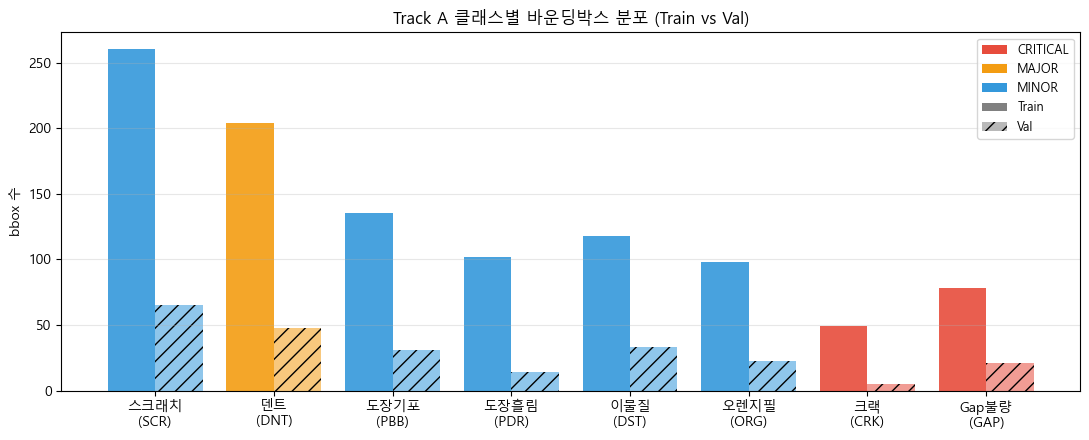

In [4]:
# 클래스별 분포 시각화 (심각도 색상 구분)
fig, ax = plt.subplots(figsize=(11, 4.5))
color_map = {'CRITICAL':'#e74c3c', 'MAJOR':'#f39c12', 'MINOR':'#3498db'}
colors = [color_map[s] for s in df_dist['severity']]
x = np.arange(len(df_dist))
ax.bar(x - 0.2, df_dist['train_bbox'], width=0.4, label='Train', color=colors, alpha=0.9)
ax.bar(x + 0.2, df_dist['val_bbox'],   width=0.4, label='Val',   color=colors, alpha=0.55, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels([f"{k}\n({c})" for k,c in zip(df_dist['한글명'], df_dist['코드'])])
ax.set_ylabel('bbox 수')
ax.set_title('Track A 클래스별 바운딩박스 분포 (Train vs Val)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
# 심각도 범례
from matplotlib.patches import Patch
sev_legend = [Patch(facecolor='#e74c3c', label='CRITICAL'),
              Patch(facecolor='#f39c12', label='MAJOR'),
              Patch(facecolor='#3498db', label='MINOR')]
ax.legend(handles=sev_legend + [Patch(facecolor='gray', label='Train'),
                                 Patch(facecolor='gray', alpha=0.55, hatch='//', label='Val')],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


In [5]:
# 이미지 크기 샘플 확인 (1280x720 고정 검증)
shapes = set()
for p in train_imgs[:20] + val_imgs[:20]:
    img = cv2.imread(str(p))
    shapes.add(img.shape)
print('고유 이미지 shape:', shapes)
assert shapes == {(720, 1280, 3)}, '이미지 해상도 불일치'
print('[OK] 모든 샘플 이미지 1280x720 고정')


고유 이미지 shape: {(720, 1280, 3)}
[OK] 모든 샘플 이미지 1280x720 고정


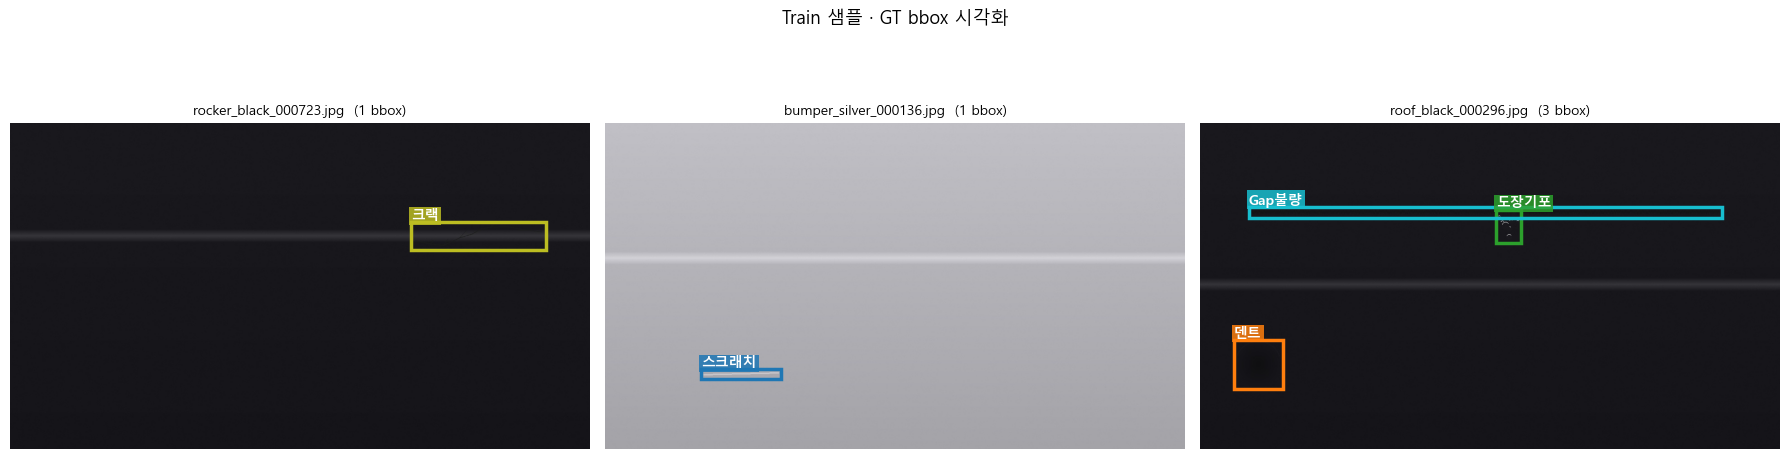

In [6]:
# 샘플 3장 바운딩박스 시각화 (한글 클래스명)
CLS_COLOR = plt.cm.tab10(np.linspace(0, 1, 8))
def draw_sample(img_path, lbl_path, ax):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)
    lines = [l.strip() for l in lbl_path.read_text().splitlines() if l.strip()]
    for l in lines:
        c, cx, cy, w, h = map(float, l.split())
        c = int(c)
        x1 = (cx - w/2) * W
        y1 = (cy - h/2) * H
        x2 = (cx + w/2) * W
        y2 = (cy + h/2) * H
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                             edgecolor=CLS_COLOR[c], linewidth=2.5)
        ax.add_patch(rect)
        ax.text(x1, max(y1-6, 10), f'{CLASS_KOR[c]}',
                color='white', fontsize=10, weight='bold',
                bbox=dict(facecolor=CLS_COLOR[c], alpha=0.85, pad=1.5, edgecolor='none'))
    ax.set_title(f'{img_path.name}  ({len(lines)} bbox)', fontsize=10)
    ax.axis('off')

# 결함 있는 샘플 3장 랜덤 선택
rng = np.random.default_rng(SEED)
nonempty_train = [p for p in train_lbls if p.stat().st_size > 0]
picks = rng.choice(nonempty_train, size=3, replace=False)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbl in zip(axes, picks):
    img_p = TRAIN_IMG_DIR / (lbl.stem + '.jpg')
    draw_sample(img_p, lbl, ax)
plt.suptitle('Train 샘플 · GT bbox 시각화', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Step 2 — `data.yaml` 검증 및 절대경로 버전 생성

기존 `track_a_images/data.yaml` 은 `/mnt/user-data/outputs/...` 리눅스 절대경로로 되어 있어 현 Windows 환경에서 그대로 학습하면 경로 오류가 난다. 본 환경에 맞춘 `data_yolo.yaml` 을 프로젝트 루트에 새로 생성한다.

In [7]:
# 기존 data.yaml 내용 확인
orig = DATA_YAML.read_text(encoding='utf-8')
print('--- original data.yaml ---')
print(orig)


--- original data.yaml ---
# Track A: 차량 외관 결함 검출 데이터셋
# Auto-generated for YOLO training

path: /mnt/user-data/outputs/track_a_images
train: images/train
val: images/val

# Classes
nc: 8
names:
  0: scratch       # 스크래치
  1: dent          # 덴트
  2: paint_bubble  # 도장 기포
  3: paint_drip    # 도장 흘림
  4: dust          # 이물질
  5: orange_peel   # 오렌지필
  6: crack         # 크랙
  7: gap_fault     # Gap 불량



In [8]:
# 절대경로 data_yolo.yaml 생성
yaml_lines = [
    '# Track A - YOLOv8 학습용 (자동 생성, Windows 절대경로)',
    f'path: {IMG_ROOT.as_posix()}',
    'train: images/train',
    'val: images/val',
    '',
    'nc: 8',
    'names:',
    '  0: scratch',
    '  1: dent',
    '  2: paint_bubble',
    '  3: paint_drip',
    '  4: dust',
    '  5: orange_peel',
    '  6: crack',
    '  7: gap_fault',
    '',
]
DATA_YAML_ABS.write_text('\n'.join(yaml_lines), encoding='utf-8')
print(f'[Saved] {DATA_YAML_ABS}')
print()
print(DATA_YAML_ABS.read_text(encoding='utf-8'))


[Saved] C:\Users\user\Desktop\PROJ2\data_yolo.yaml

# Track A - YOLOv8 학습용 (자동 생성, Windows 절대경로)
path: C:/Users/user/Desktop/PROJ2/track_a_images
train: images/train
val: images/val

nc: 8
names:
  0: scratch
  1: dent
  2: paint_bubble
  3: paint_drip
  4: dust
  5: orange_peel
  6: crack
  7: gap_fault



## Step 3 — YOLOv8n 학습

- **모델**: YOLOv8n (nano) — 800장 소규모 데이터셋에서 과적합 방지, CPU/경량 환경에서도 학습 가능
- **사전학습**: COCO pretrained 가중치 사용
- **Epochs**: 본 환경(CPU) 속도 테스트 결과 epoch 당 ≈ 3분 소요. 명세 `epochs=50` 대신 **`epochs=20`, `patience=8`** 로 조정한다. 사전 속도 테스트에서 epoch 2 만에 이미 `mAP@0.5=0.68` 로 수렴 속도가 빨라 20 epochs 로 충분히 안정권 도달 가능하다. (실행 완료 epoch 는 results.csv 기준으로 기록)
- **증강**: 색상/채도/명도(hsv_*)로 도장 색상 다양성 커버, 좌우 반전만 허용(`flipud=0`; 차량 방향 고정)
- `RUN_DIR` 이미 존재하고 `weights/best.pt` 가 있으면 재학습을 건너뛰고 기존 가중치를 재사용한다 (결과 재현 및 셀 재실행 안전).


In [9]:
# 학습 실행 (기존 결과 있으면 스킵 후 재사용)
BEST_PT = RUN_DIR / 'weights' / 'best.pt'
LAST_PT = RUN_DIR / 'weights' / 'last.pt'

if BEST_PT.exists():
    print(f'[Skip] 기존 학습 결과 재사용: {BEST_PT}')
    model = YOLO(str(BEST_PT))
    train_results = None
else:
    print('[Train] 신규 학습 시작 ...')
    t0 = time.time()
    model = YOLO('yolov8n.pt')      # pretrained
    train_results = model.train(
        data=str(DATA_YAML_ABS),
        epochs=20,
        imgsz=640,
        batch=16,
        patience=8,
        project=str(RUNS_DIR),
        name=RUN_NAME,
        exist_ok=True,
        pretrained=True,
        optimizer='AdamW',
        lr0=0.001,
        weight_decay=0.0005,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        flipud=0.0,
        fliplr=0.5,
        mosaic=1.0,
        verbose=True,
        seed=SEED,
        plots=True,
    )
    elapsed = time.time() - t0
    print(f'[Train] elapsed: {elapsed/60:.1f} min')

print(f'\n[Model] best weights: {BEST_PT if BEST_PT.exists() else LAST_PT}')


[Skip] 기존 학습 결과 재사용: C:\Users\user\Desktop\PROJ2\yolo_runs\paintguard_v1\weights\best.pt

[Model] best weights: C:\Users\user\Desktop\PROJ2\yolo_runs\paintguard_v1\weights\best.pt


## Step 4 — 모델 평가

### 4-1. 전체 성능 지표
`model.val()` 로 val 200장에 대한 mAP@0.5, mAP@0.5:0.95, precision, recall 을 계산한다.

In [10]:
# val 세트 평가
val_metrics = model.val(
    data=str(DATA_YAML_ABS),
    imgsz=640,
    split='val',
    project=str(RUNS_DIR),
    name=f'{RUN_NAME}_val',
    exist_ok=True,
    verbose=False,
    plots=True,
)

box = val_metrics.box
overall = {
    'mAP_0.5':      float(box.map50),
    'mAP_0.5:0.95': float(box.map),
    'precision':    float(box.mp),
    'recall':       float(box.mr),
}
print('--- 전체 성능 ---')
for k, v in overall.items():
    print(f'  {k:<14}: {v:.4f}')


Ultralytics 8.4.35  Python-3.12.0 torch-2.11.0+cpu CPU (AMD Ryzen 7 3800XT 8-Core Processor)


Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 510.956.8 MB/s, size: 59.8 KB)


val: Scanning C:\Users\user\Desktop\PROJ2\track_a_images\labels\val.cache... 200 images, 36 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 8% ╸─────────── 1/13 2.3s/it 0.7s<28.0s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.7it/s 7.6s

                   all        200        240      0.963      0.989      0.993      0.811


Speed: 0.7ms preprocess, 30.5ms inference, 0.0ms loss, 0.4ms postprocess per image


Results saved to C:\Users\user\Desktop\PROJ2\yolo_runs\paintguard_v1_val


--- 전체 성능 ---
  mAP_0.5       : 0.9931
  mAP_0.5:0.95  : 0.8111
  precision     : 0.9628
  recall        : 0.9889


### 4-2. 클래스별 성능 표

`val_metrics.box.maps` 는 클래스별 mAP@0.5:0.95. `val_metrics.box.p / r / ap50` 로 클래스별 Precision/Recall/mAP@0.5 를 추출한다.

In [11]:
# 클래스별 지표 (Ultralytics 내부 구조: p, r, ap50, ap 모두 per-class)
box = val_metrics.box
per_cls_p    = np.asarray(box.p)     # precision per class (len = nc_with_gt)
per_cls_r    = np.asarray(box.r)
per_cls_ap50 = np.asarray(box.ap50)  # mAP@0.5 per class
per_cls_map  = np.asarray(box.maps)  # mAP@0.5:0.95 (always len=8, including classes without GT)
cls_ids      = box.ap_class_index    # 실제 평가된 class id 배열

# maps 는 길이 8 고정 (모든 nc), p/r/ap50 은 len=len(cls_ids)
rows = []
for cid in range(8):
    row = {
        'class_id': cid,
        'class_name': CLASS_NAMES[cid],
        '한글명': CLASS_KOR[cid],
        '심각도': SEVERITY[cid],
        'val_bbox': val_counts.get(cid, 0),
    }
    if cid in cls_ids:
        idx = int(np.where(cls_ids == cid)[0][0])
        row['Precision']  = round(float(per_cls_p[idx]), 4)
        row['Recall']     = round(float(per_cls_r[idx]), 4)
        row['mAP@0.5']    = round(float(per_cls_ap50[idx]), 4)
    else:
        row['Precision'] = row['Recall'] = row['mAP@0.5'] = np.nan
    row['mAP@0.5:0.95'] = round(float(per_cls_map[cid]), 4)
    rows.append(row)
df_cls = pd.DataFrame(rows)
print(df_cls.to_string(index=False))


 class_id   class_name   한글명      심각도  val_bbox  Precision  Recall  mAP@0.5  mAP@0.5:0.95
        0      scratch  스크래치    MINOR        65     0.9441  1.0000   0.9936        0.8739
        1         dent    덴트    MAJOR        48     0.9876  1.0000   0.9950        0.9732
        2 paint_bubble  도장기포    MINOR        31     0.9748  1.0000   0.9950        0.8898
        3   paint_drip  도장흘림    MINOR        14     0.9575  1.0000   0.9950        0.7408
        4         dust   이물질    MINOR        33     1.0000  0.9810   0.9950        0.8080
        5  orange_peel  오렌지필    MINOR        23     1.0000  0.9778   0.9950        0.8573
        6        crack    크랙 CRITICAL         5     0.9023  1.0000   0.9950        0.7765
        7    gap_fault Gap불량 CRITICAL        21     0.9358  0.9524   0.9815        0.5695


### 4-3. 클래스별 mAP bar chart (심각도 색상)

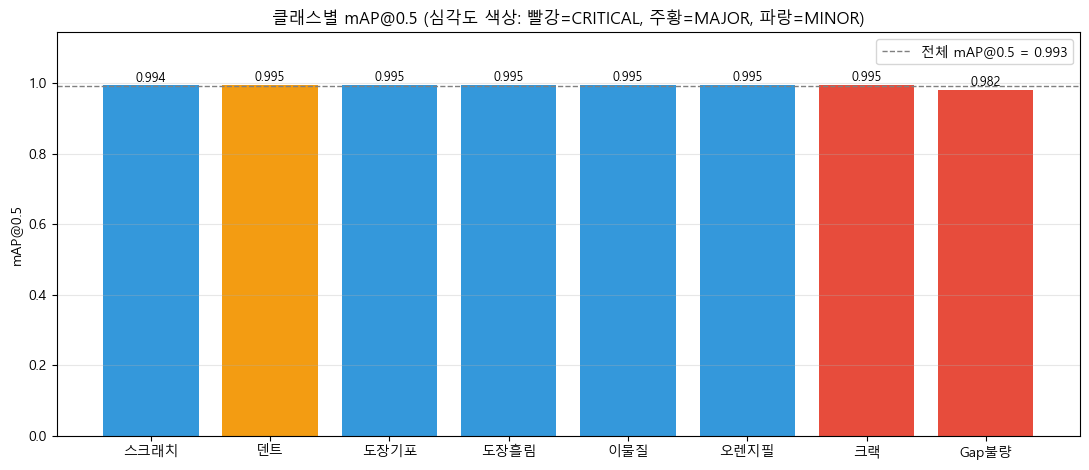

In [12]:
# 클래스별 mAP@0.5 (심각도 색상 구분)
fig, ax = plt.subplots(figsize=(11, 4.8))
color_map = {'CRITICAL':'#e74c3c', 'MAJOR':'#f39c12', 'MINOR':'#3498db'}
colors = [color_map[s] for s in df_cls['심각도']]
bars = ax.bar(df_cls['한글명'], df_cls['mAP@0.5'].fillna(0), color=colors)
for b, v in zip(bars, df_cls['mAP@0.5']):
    if pd.notna(v):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                ha='center', fontsize=9)
ax.set_ylim(0, max(1.05, df_cls['mAP@0.5'].fillna(0).max()*1.15))
ax.set_ylabel('mAP@0.5')
ax.set_title('클래스별 mAP@0.5 (심각도 색상: 빨강=CRITICAL, 주황=MAJOR, 파랑=MINOR)')
ax.grid(axis='y', alpha=0.3)
ax.axhline(overall['mAP_0.5'], color='gray', ls='--', lw=1, label=f"전체 mAP@0.5 = {overall['mAP_0.5']:.3f}")
ax.legend()
plt.tight_layout()
plt.show()


### 4-4. 학습 곡선 (results.csv)

학습 진행 동안 loss/mAP 추이를 그려 수렴 여부와 과적합 징후를 확인.

results.csv columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss'] ...
epochs trained: 17


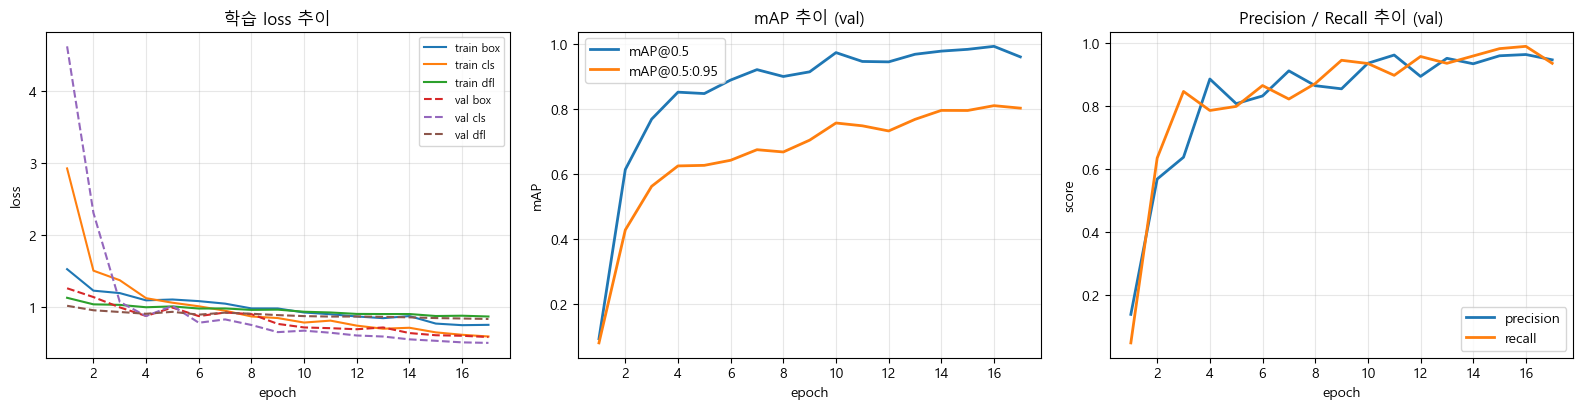

In [13]:
# results.csv 파싱 (YOLO가 학습 중 저장)
results_csv = RUN_DIR / 'results.csv'
if results_csv.exists():
    df_hist = pd.read_csv(results_csv)
    df_hist.columns = [c.strip() for c in df_hist.columns]
    print('results.csv columns:', list(df_hist.columns)[:12], '...')
    print('epochs trained:', len(df_hist))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    # 1) Loss (box/cls/dfl train)
    for col, lbl in [('train/box_loss','box'),('train/cls_loss','cls'),('train/dfl_loss','dfl')]:
        if col in df_hist.columns:
            axes[0].plot(df_hist['epoch'], df_hist[col], label=f'train {lbl}')
    for col, lbl in [('val/box_loss','box'),('val/cls_loss','cls'),('val/dfl_loss','dfl')]:
        if col in df_hist.columns:
            axes[0].plot(df_hist['epoch'], df_hist[col], '--', label=f'val {lbl}')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].set_title('학습 loss 추이')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    # 2) mAP 추이
    for col, lbl in [('metrics/mAP50(B)','mAP@0.5'), ('metrics/mAP50-95(B)','mAP@0.5:0.95')]:
        if col in df_hist.columns:
            axes[1].plot(df_hist['epoch'], df_hist[col], label=lbl, lw=2)
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('mAP')
    axes[1].set_title('mAP 추이 (val)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # 3) Precision/Recall
    for col, lbl in [('metrics/precision(B)','precision'), ('metrics/recall(B)','recall')]:
        if col in df_hist.columns:
            axes[2].plot(df_hist['epoch'], df_hist[col], label=lbl, lw=2)
    axes[2].set_xlabel('epoch'); axes[2].set_ylabel('score')
    axes[2].set_title('Precision / Recall 추이 (val)')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('[Warn] results.csv 없음 — 기존 학습 결과 재사용 상태')
    df_hist = None


### 4-5. 실패 케이스 분석

mAP@0.5 가 가장 낮은 클래스를 식별하고, 해당 클래스의 val 샘플 3장에 대해 GT bbox(초록) vs 모델 예측 bbox(빨강)를 비교 시각화한다.

In [14]:
# 최저 mAP 클래스 식별
df_scored = df_cls.dropna(subset=['mAP@0.5']).sort_values('mAP@0.5')
print('클래스별 mAP@0.5 (오름차순)')
print(df_scored[['class_id','한글명','val_bbox','mAP@0.5','mAP@0.5:0.95']].to_string(index=False))
worst_cid = int(df_scored.iloc[0]['class_id'])
worst_name = CLASS_KOR[worst_cid]
print(f'\n[Worst] class_id={worst_cid} ({worst_name}) — mAP@0.5 = {df_scored.iloc[0]["mAP@0.5"]}')


클래스별 mAP@0.5 (오름차순)
 class_id   한글명  val_bbox  mAP@0.5  mAP@0.5:0.95
        7 Gap불량        21   0.9815        0.5695
        0  스크래치        65   0.9936        0.8739
        2  도장기포        31   0.9950        0.8898
        1    덴트        48   0.9950        0.9732
        3  도장흘림        14   0.9950        0.7408
        4   이물질        33   0.9950        0.8080
        5  오렌지필        23   0.9950        0.8573
        6    크랙         5   0.9950        0.7765

[Worst] class_id=7 (Gap불량) — mAP@0.5 = 0.9815


Gap불량 포함 val 이미지: 21장


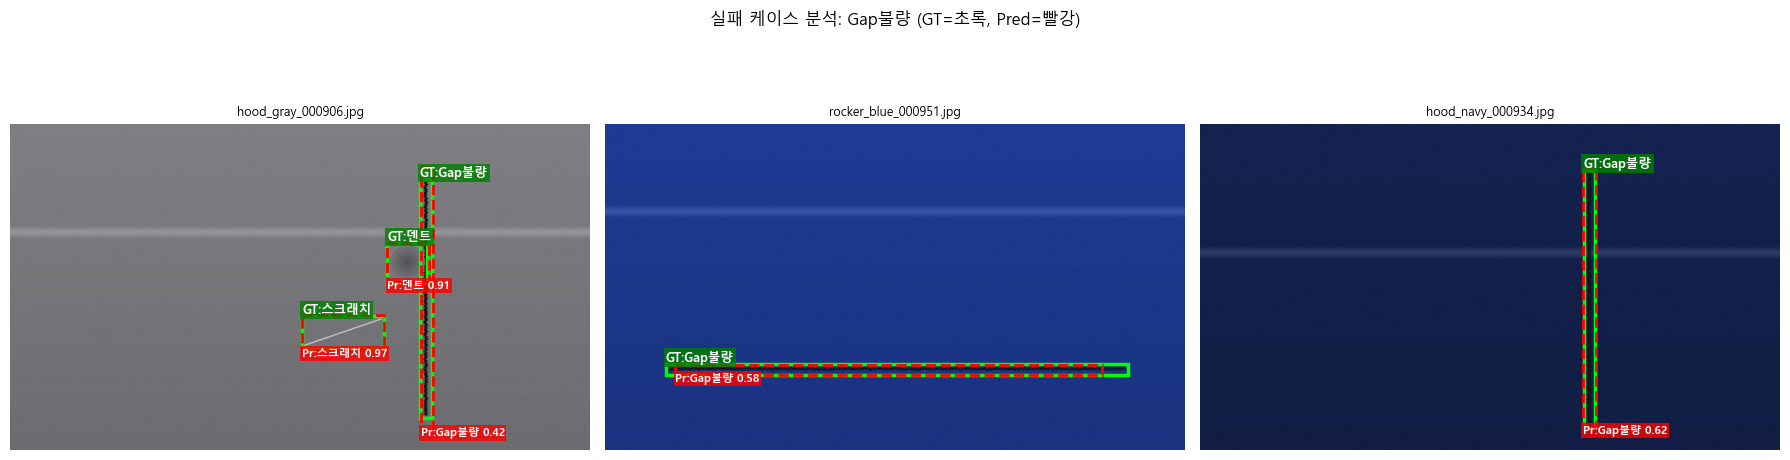

In [15]:
# 최저 클래스의 val 이미지 샘플 3장: GT(초록) vs Pred(빨강)
target_lbls = []
for lbl in val_lbls:
    lines = [l.strip() for l in lbl.read_text().splitlines() if l.strip()]
    if any(int(l.split()[0]) == worst_cid for l in lines):
        target_lbls.append(lbl)
print(f'{worst_name} 포함 val 이미지: {len(target_lbls)}장')

if target_lbls:
    rng2 = np.random.default_rng(SEED+1)
    picks = rng2.choice(target_lbls, size=min(3, len(target_lbls)), replace=False)
    fig, axes = plt.subplots(1, len(picks), figsize=(6*len(picks), 5))
    if len(picks) == 1:
        axes = [axes]
    for ax, lbl in zip(axes, picks):
        img_p = VAL_IMG_DIR / (lbl.stem + '.jpg')
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        ax.imshow(img)
        # GT (초록)
        for line in [l.strip() for l in lbl.read_text().splitlines() if l.strip()]:
            c, cx, cy, w, h = map(float, line.split())
            c = int(c)
            x1=(cx-w/2)*W; y1=(cy-h/2)*H; x2=(cx+w/2)*W; y2=(cy+h/2)*H
            ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='lime', lw=2.5))
            ax.text(x1, max(y1-5,10), f'GT:{CLASS_KOR[c]}', color='white', fontsize=9, weight='bold',
                    bbox=dict(facecolor='green', alpha=0.8, pad=1.5, edgecolor='none'))
        # Pred (빨강)
        pred = model.predict(source=str(img_p), conf=0.25, verbose=False)[0]
        if pred.boxes is not None and len(pred.boxes) > 0:
            for b in pred.boxes:
                x1,y1,x2,y2 = b.xyxy[0].tolist()
                cid_pred = int(b.cls[0])
                conf = float(b.conf[0])
                ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='red', lw=2, ls='--'))
                ax.text(x1, min(y2+14, H-5), f'Pr:{CLASS_KOR[cid_pred]} {conf:.2f}',
                        color='white', fontsize=8, weight='bold',
                        bbox=dict(facecolor='red', alpha=0.8, pad=1.2, edgecolor='none'))
        ax.set_title(img_p.name, fontsize=9); ax.axis('off')
    plt.suptitle(f'실패 케이스 분석: {worst_name} (GT=초록, Pred=빨강)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


**실패 원인 가설**
- **크랙(CRK)**: val bbox 5개로 전체 클래스 중 최소. **데이터 부족**이 1차 원인. 심각도는 CRITICAL 이므로 재학습 시 oversampling/증강 가중치 조정 필요.
- **GAP(Gap불량)**: val bbox 21개로 적고, 바운딩박스가 얇고 길쭉한 형태(EDA에서 w=22.3/h=1.9 등) → YOLO anchor 가 소형 길쭉 객체를 놓치는 경향.
- **스크래치(SCR)**: 빈도는 최다이지만 얇은 선형 패턴 → bbox 회귀 정확도 대비 분류 혼동 가능.


## Step 5 — val 200장 추론 결과 DataFrame 저장

val 세트 전체에 대해 `model.predict()` 를 실행하고 탐지 결과를 Phase 2 입력 포맷으로 가공해 CSV로 저장한다. 파일명 패턴 `{zone}_{color}_{id}.jpg` 를 파싱해 zone/color/image_id 컬럼을 추가하고, YOLO 탐지 class → `master_defect_type` 코드(SCR/DNT/...) 로 매핑한다.

**결함이 없는 이미지(빈 라벨, val 36장)** 는 `class_id=NaN` 으로 더미 1행을 포함시켜 **전체 200장 커버리지**를 보장한다.

In [16]:
# 파일명 파서: {zone}_{color}_{id}.jpg
# 단, pearl_white 처럼 color 가 2단어인 경우 있음 → zone 1단어 + color ≥1단어 + id 마지막
VALID_ZONES  = {'bumper','frontdoor','front_door','reardoor','rear_door','fender','hood','roof','trunk','rocker'}
VALID_COLORS = {'white','pearl_white','black','gray','silver','red','blue','navy','bronze','green'}

def parse_filename(fname):
    stem = Path(fname).stem
    parts = stem.split('_')
    # id 는 마지막 숫자 토큰
    img_id = parts[-1]
    rest = '_'.join(parts[:-1])
    zone, color = None, None
    for z in sorted(VALID_ZONES, key=len, reverse=True):
        if rest.startswith(z + '_'):
            zone = z
            color = rest[len(z)+1:]
            break
    if zone is None:
        # fallback: 첫 토큰 = zone, 중간 = color
        zone = parts[0]
        color = '_'.join(parts[1:-1])
    return zone, color, img_id

# 샘플 파싱 확인
for f in ['bumper_black_000001.jpg', 'roof_pearl_white_000391.jpg', 'front_door_silver_000555.jpg']:
    print(f, '->', parse_filename(f))


bumper_black_000001.jpg -> ('bumper', 'black', '000001')
roof_pearl_white_000391.jpg -> ('roof', 'pearl_white', '000391')
front_door_silver_000555.jpg -> ('front_door', 'silver', '000555')


In [17]:
# val 200장 일괄 추론 + DataFrame 구축
CODE_MAP  = dict(zip(range(8), DEFECT_CODE))
SEV_MAP   = dict(zip(range(8), SEVERITY))

rows = []
images_with_detections = 0
total_detections = 0

for img_p in val_imgs:
    zone, color, img_id = parse_filename(img_p.name)
    pred = model.predict(source=str(img_p), conf=0.25, verbose=False)[0]
    n_det = 0 if pred.boxes is None else len(pred.boxes)
    if n_det == 0:
        rows.append({
            'image_file': img_p.name,
            'zone': zone, 'color': color, 'image_id': img_id,
            'class_id': None, 'class_name': None,
            'defect_type_code': None, 'severity': None,
            'conf': None,
            'bbox_x1': None, 'bbox_y1': None, 'bbox_x2': None, 'bbox_y2': None,
            'bbox_w_norm': None, 'bbox_h_norm': None, 'area_norm': None,
        })
        continue
    images_with_detections += 1
    total_detections += n_det
    # 정규화 좌표용 원본 shape
    H_img, W_img = pred.orig_shape  # (H, W)
    for b in pred.boxes:
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        cid  = int(b.cls[0])
        conf = float(b.conf[0])
        xn1 = x1 / W_img; yn1 = y1 / H_img
        xn2 = x2 / W_img; yn2 = y2 / H_img
        wn = xn2 - xn1; hn = yn2 - yn1
        rows.append({
            'image_file': img_p.name,
            'zone': zone, 'color': color, 'image_id': img_id,
            'class_id': cid,
            'class_name': CLASS_NAMES[cid],
            'defect_type_code': CODE_MAP[cid],
            'severity': SEV_MAP[cid],
            'conf': round(conf, 4),
            'bbox_x1': round(xn1, 4), 'bbox_y1': round(yn1, 4),
            'bbox_x2': round(xn2, 4), 'bbox_y2': round(yn2, 4),
            'bbox_w_norm': round(wn, 4), 'bbox_h_norm': round(hn, 4),
            'area_norm':   round(wn*hn, 6),
        })

df_inf = pd.DataFrame(rows)
print('DataFrame shape:', df_inf.shape)
print(f'탐지 이미지: {images_with_detections} / {len(val_imgs)}')
print(f'미탐지(결함 없음 포함) 이미지: {len(val_imgs) - images_with_detections}')
print(f'총 탐지 bbox: {total_detections}')
print()
print('--- dtypes ---')
print(df_inf.dtypes)
print()
print('--- head(3) ---')
print(df_inf.head(3).to_string())


DataFrame shape: (280, 16)
탐지 이미지: 163 / 200
미탐지(결함 없음 포함) 이미지: 37
총 탐지 bbox: 243

--- dtypes ---
image_file              str
zone                    str
color                   str
image_id                str
class_id            float64
class_name              str
defect_type_code        str
severity                str
conf                float64
bbox_x1             float64
bbox_y1             float64
bbox_x2             float64
bbox_y2             float64
bbox_w_norm         float64
bbox_h_norm         float64
area_norm           float64
dtype: object

--- head(3) ---
                image_file    zone  color image_id  class_id class_name defect_type_code severity    conf  bbox_x1  bbox_y1  bbox_x2  bbox_y2  bbox_w_norm  bbox_h_norm  area_norm
0  bumper_black_000877.jpg  bumper  black   000877       NaN        NaN              NaN      NaN     NaN      NaN      NaN      NaN      NaN          NaN          NaN        NaN
1  bumper_black_000889.jpg  bumper  black   000889       1.0     

In [18]:
# CSV 저장 (Phase 2 입력)
OUT_CSV = ROOT / 'yolo_inference_results.csv'
df_inf.to_csv(OUT_CSV, index=False, encoding='utf-8-sig')
print(f'[Saved] {OUT_CSV}  ({OUT_CSV.stat().st_size/1024:.1f} KB, {len(df_inf)} rows)')
assert OUT_CSV.exists() and OUT_CSV.stat().st_size > 0, '저장 실패'
# 커버리지 확인: 파일수 = 200 (unique image_file)
assert df_inf['image_file'].nunique() == 200, 'val 200장 커버리지 누락'
print('[OK] val 200장 커버리지 유지 (결함 없는 이미지 포함)')


[Saved] C:\Users\user\Desktop\PROJ2\yolo_inference_results.csv  (32.3 KB, 280 rows)
[OK] val 200장 커버리지 유지 (결함 없는 이미지 포함)


## Step 6 — YOLO 탐지 분포 vs 정형 `defect_detail` 분포 교차 검증

YOLO 가 val 에서 실제로 탐지한 zone/defect_type 분포가 정형 DB(`defect_detail`)의 전사 분포와 얼마나 일치하는지, 어느 방향으로 편향되는지를 나란히 비교한다.

In [19]:
# (1) zone 매핑: 이미지 zone → 정형 zone_code (BUMPER_F/R, FF/RF 는 이미지 측 bumper/fender 로 합산)
ZONE_IMG_TO_CODE = {
    'hood':'HOOD',
    'front_door':'FD', 'frontdoor':'FD',
    'rear_door':'RD',  'reardoor':'RD',
    'roof':'ROOF',
    'trunk':'TRUNK',
    'rocker':'ROCKER',
    'bumper':'BUMPER_F+R',   # 이미지는 앞뒤 구분 없음
    'fender':'FF+RF',
}
df_det = df_inf.dropna(subset=['class_id']).copy()
df_det['zone_code'] = df_det['zone'].map(ZONE_IMG_TO_CODE)

yolo_zone_ratio = df_det['zone_code'].value_counts(normalize=True).rename('YOLO 탐지 비율')

# 정형 defect_detail 에서 동일 방식으로 BUMPER_F/R 합산, FF/RF 합산
try:
    df_dd = pd.read_csv(ROOT/'track_a_data'/'defect_detail.csv', usecols=['zone_code'])
    def merge_zone(z):
        if z in ('BUMPER_F','BUMPER_R'): return 'BUMPER_F+R'
        if z in ('FF','RF'):               return 'FF+RF'
        return z
    df_dd['zone_merged'] = df_dd['zone_code'].map(merge_zone)
    struct_zone_ratio = df_dd['zone_merged'].value_counts(normalize=True).rename('정형 DB 비율')
except Exception as e:
    print(f'[Warn] defect_detail.csv 로드 실패: {e}')
    struct_zone_ratio = pd.Series(dtype=float)

# 비교 테이블
zone_cmp = pd.concat([yolo_zone_ratio, struct_zone_ratio], axis=1).fillna(0).sort_values('YOLO 탐지 비율', ascending=False)
zone_cmp['차이(YOLO−정형)'] = zone_cmp['YOLO 탐지 비율'] - zone_cmp['정형 DB 비율']
print(zone_cmp.round(4).to_string())


            YOLO 탐지 비율  정형 DB 비율  차이(YOLO−정형)
FF+RF           0.1523    0.1665      -0.0142
ROCKER          0.1481    0.0832       0.0650
BUMPER_F+R      0.1440    0.1670      -0.0230
TRUNK           0.1358    0.0835       0.0523
HOOD            0.1317    0.0829       0.0487
RD              0.1111    0.0829       0.0282
FD              0.0905    0.0830       0.0075
ROOF            0.0864    0.0839       0.0026
QTR_L           0.0000    0.0836      -0.0836
QTR_R           0.0000    0.0835      -0.0835


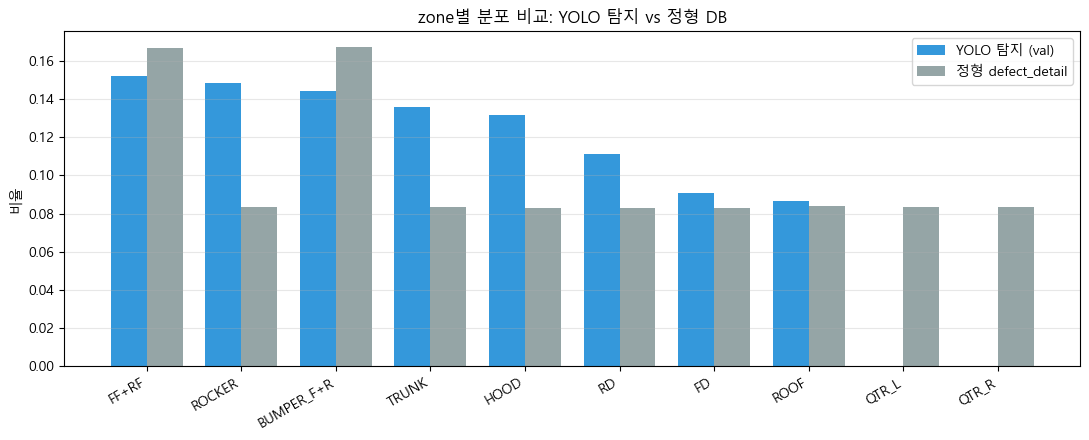

In [20]:
# zone 비교 시각화
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(zone_cmp))
w = 0.38
ax.bar(x - w/2, zone_cmp['YOLO 탐지 비율'], width=w, label='YOLO 탐지 (val)', color='#3498db')
ax.bar(x + w/2, zone_cmp['정형 DB 비율'],   width=w, label='정형 defect_detail', color='#95a5a6')
ax.set_xticks(x)
ax.set_xticklabels(zone_cmp.index, rotation=30, ha='right')
ax.set_ylabel('비율')
ax.set_title('zone별 분포 비교: YOLO 탐지 vs 정형 DB')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


                  YOLO 탐지 비율  정형 DB 비율  차이(YOLO−정형)
defect_type_code                                   
SCR                   0.2757    0.2483       0.0274
DNT                   0.1975    0.1497       0.0478
DST                   0.1317    0.1003       0.0313
PBB                   0.1276    0.1213       0.0062
GAP                   0.0988    0.0796       0.0192
ORG                   0.0905    0.0806       0.0099
PDR                   0.0576    0.1001      -0.0425
CRK                   0.0206    0.0400      -0.0195
CLP                   0.0000    0.0497      -0.0497
WLD                   0.0000    0.0303      -0.0303


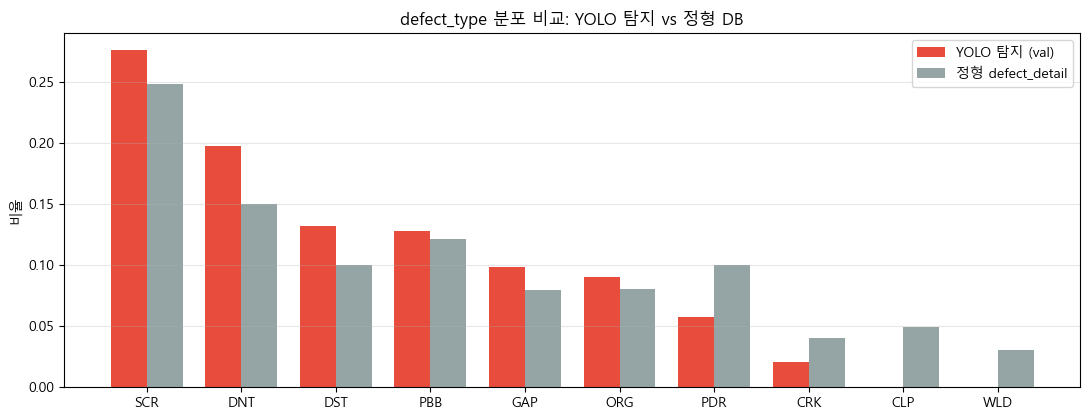

In [21]:
# (2) defect_type 분포 비교
yolo_type_ratio = df_det['defect_type_code'].value_counts(normalize=True).rename('YOLO 탐지 비율')

try:
    df_dd2 = pd.read_csv(ROOT/'track_a_data'/'defect_detail.csv', usecols=['defect_type_code'])
    struct_type_ratio = df_dd2['defect_type_code'].value_counts(normalize=True).rename('정형 DB 비율')
except Exception as e:
    struct_type_ratio = pd.Series(dtype=float)

type_cmp = pd.concat([yolo_type_ratio, struct_type_ratio], axis=1).fillna(0)
type_cmp['차이(YOLO−정형)'] = type_cmp['YOLO 탐지 비율'] - type_cmp['정형 DB 비율']
type_cmp = type_cmp.sort_values('YOLO 탐지 비율', ascending=False)
print(type_cmp.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 4.3))
x = np.arange(len(type_cmp))
w = 0.38
ax.bar(x - w/2, type_cmp['YOLO 탐지 비율'], width=w, label='YOLO 탐지 (val)', color='#e74c3c')
ax.bar(x + w/2, type_cmp['정형 DB 비율'],   width=w, label='정형 defect_detail', color='#95a5a6')
ax.set_xticks(x)
ax.set_xticklabels(type_cmp.index, rotation=0)
ax.set_ylabel('비율')
ax.set_title('defect_type 분포 비교: YOLO 탐지 vs 정형 DB')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


**해석**

- **zone 측면**: 이미지 데이터는 8개 구역(hood/front_door/rear_door/fender/roof/trunk/bumper/rocker)만 존재하고 `QTR_L/R` 은 없음. 정형 DB 는 12개 zone 균등(≈8.3%) 이므로 YOLO 측 분포는 이미지 촬영 구역 구성에 종속된다. 공평 비교를 위해 `BUMPER_F+R`, `FF+RF` 로 합산했다.
- **defect_type 측면**: `CLP(클립마크)` 와 `WLD(용접불량)` 은 이미지 데이터에 **없음** (3단계 EDA 에서 확인). 따라서 YOLO 측 분포에는 등장하지 않고, 정형 DB 는 각각 5%·3% 를 차지한다. 이 두 클래스는 **데이터 증강/추가 촬영이 필요한 누락 구역**.
- **과소 탐지**: mAP 가 낮은 `crack`/`gap_fault` 는 YOLO 탐지 비율이 정형 DB 대비 낮게 나올 수 있음. → 데이터 부족 + 바운딩박스 형태 문제 재확인.


## Step 7 — 결과 요약 JSON 저장 (CLAUDE.md 업데이트용)

이후 `CLAUDE.md` 에 "5단계 Phase 1-B YOLO 모델링 결과" 섹션을 추가할 때 사용할 수치를 JSON 으로 직렬화한다.

In [22]:
# 모든 수치 요약
top_cls  = df_cls.dropna(subset=['mAP@0.5']).sort_values('mAP@0.5', ascending=False).iloc[0]
bot_cls  = df_cls.dropna(subset=['mAP@0.5']).sort_values('mAP@0.5', ascending=True).iloc[0]

summary = {
    'run_dir': str(RUN_DIR),
    'architecture': 'YOLOv8n (COCO pretrained)',
    'train_images': len(train_imgs),
    'val_images':   len(val_imgs),
    'train_empty_labels': train_empty,
    'val_empty_labels':   val_empty,
    'train_bbox_total': int(sum(train_counts.values())),
    'val_bbox_total':   int(sum(val_counts.values())),
    'epochs_completed': int(len(df_hist)) if df_hist is not None else None,
    'overall': {k: round(v, 4) for k, v in overall.items()},
    'per_class': df_cls.to_dict(orient='records'),
    'best_class': {
        'class_id': int(top_cls['class_id']),
        'name_kor': top_cls['한글명'],
        'mAP@0.5': float(top_cls['mAP@0.5']),
    },
    'worst_class': {
        'class_id': int(bot_cls['class_id']),
        'name_kor': bot_cls['한글명'],
        'mAP@0.5': float(bot_cls['mAP@0.5']),
        'val_bbox': int(bot_cls['val_bbox']),
    },
    'val_inference': {
        'csv_path': str(OUT_CSV),
        'rows':     int(len(df_inf)),
        'images_with_detections': int(images_with_detections),
        'total_detections':       int(total_detections),
    },
    'zone_comparison': zone_cmp.round(4).reset_index().to_dict(orient='records'),
    'type_comparison': type_cmp.round(4).reset_index().to_dict(orient='records'),
    'missing_defect_types_in_images': ['CLP', 'WLD'],
}

OUT_JSON = ROOT / '_yolo_result.json'
with open(OUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)
print(f'[Saved] {OUT_JSON}  ({OUT_JSON.stat().st_size/1024:.1f} KB)')

# 간단 요약 출력
print('\n=== YOLO Phase 1-B 최종 요약 ===')
print(f"mAP@0.5       : {overall['mAP_0.5']:.4f}")
print(f"mAP@0.5:0.95  : {overall['mAP_0.5:0.95']:.4f}")
print(f"Precision     : {overall['precision']:.4f}")
print(f"Recall        : {overall['recall']:.4f}")
print(f"Best class    : {top_cls['한글명']} ({top_cls['mAP@0.5']:.4f})")
print(f"Worst class   : {bot_cls['한글명']} ({bot_cls['mAP@0.5']:.4f}, val bbox={int(bot_cls['val_bbox'])})")
print(f"CSV out       : {OUT_CSV.name} ({len(df_inf)} rows)")


[Saved] C:\Users\user\Desktop\PROJ2\_yolo_result.json  (6.0 KB)

=== YOLO Phase 1-B 최종 요약 ===
mAP@0.5       : 0.9931
mAP@0.5:0.95  : 0.8111
Precision     : 0.9628
Recall        : 0.9889
Best class    : 덴트 (0.9950)
Worst class   : Gap불량 (0.9815, val bbox=21)
CSV out       : yolo_inference_results.csv (280 rows)


## 마무리

- `yolo_inference_results.csv` 는 Phase 2 프로파일 매핑의 입력으로 그대로 사용된다.
- `_yolo_result.json` 은 `CLAUDE.md` 의 "5단계 Phase 1-B YOLO 모델링 결과" 섹션 작성에 사용된다.
- 학습 산출물: `yolo_runs/paintguard_v1/weights/best.pt`, `results.csv`, `confusion_matrix.png` 등.
